<a href="https://colab.research.google.com/github/muskang48/SurvCI/blob/main/surv_ci_info_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Loading Libraries 
!pip install lifelines
import pandas as pd
import numpy as np
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

     |████████████████████████████████| 348 kB 5.3 MB/s 
     |████████████████████████████████| 55 kB 3.6 MB/s 
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4048 sha256=0bc82f95f467743a508ff66d6f30aa49f824f7d78189cfdbafab893079736c4e
  Stored in directory: /root/.cache/pip/wheels/9f/01/ee/1331593abb5725ff7d8c1333aee93a50a1c29d6ddda9665c9f
Successfully built autograd-gamma


# ACTG-Semi Synthetic (Informative)

In [ ]:
#Loading Dataset 
# df = pd.read_csv('/content/actg_semi_info.csv')
df = pd.read_csv('/content/drive/MyDrive/Surv_CI/data/actg_semi_info_new.csv')
#Pre-processing Features
x = df.iloc[:,0:23]
x = SimpleImputer(missing_values=np.nan, strategy='mean').fit_transform(x)
x = StandardScaler().fit_transform(x)

n = len(x)
W = np.array(df['W']) #Treatment Indicator
y_f = np.array(df['y_f']) #Factual Outcome
e_f = np.array(df['e_f'])
t_f = np.array(df['t_f'])
y_cf = np.array(df['y_cf']) #CounterFactual Outcome
e_cf = np.array(df['e_cf'])
t_cf = np.array(df['t_cf']) 
c_f = np.array(df['c_f']) #Factual censoring time 
c_cf = np.array(df['c_cf']) #CounterFactual censoring time

np.random.seed(31415)
idx = np.arange(0, n)
np.random.shuffle(idx)
end_time = max(y_f)
print("end_time:{}".format(end_time))
print("event rate:{}".format(sum(e_f) / len(e_f)))
print("treatment rate:{}".format(sum(W) / len(W)))
num_examples = int(0.80 * len(e_f))
print("num_examples:{}".format(num_examples))
train_idx = idx[0: num_examples]
split = int((n - num_examples) / 2)
test_idx = idx[num_examples: num_examples + split]
valid_idx = idx[num_examples + split: n]

x_train, x_test, x_val = x[train_idx], x[test_idx], x[valid_idx]
yf_train, yf_test, yf_val = y_f[train_idx], y_f[test_idx], y_f[valid_idx]
ycf_train, ycf_test, ycf_val = y_cf[train_idx], y_cf[test_idx], y_cf[valid_idx]
tf_train, tf_test, tf_val = t_f[train_idx], t_f[test_idx], t_f[valid_idx]
tcf_train, tcf_test, tcf_val = t_cf[train_idx], t_cf[test_idx], t_cf[valid_idx]
ef_train, ef_test, ef_val = e_f[train_idx], e_f[test_idx], e_f[valid_idx]
ecf_train, ecf_test, ecf_val = e_cf[train_idx], e_cf[test_idx], e_cf[valid_idx]
cf_train, cf_test, cf_val = c_f[train_idx], c_f[test_idx], c_f[valid_idx]
ccf_train, ccf_test, ccf_val = c_cf[train_idx], c_cf[test_idx], c_cf[valid_idx]
W_train, W_test, W_val = W[train_idx], W[test_idx], W[valid_idx]

end_time:3482.597882266782
event rate:0.5605423094904161
treatment rate:0.5558672276764843
num_examples:1711


# Synthetic (Informative)

In [ ]:
#Loading Dataset 
#df = pd.read_csv('/content/data/synthetic_info.csv')
#df = pd.read_csv('/content/drive/MyDrive/Surv_CI/data/synthetic_info.csv')
df = pd.read_csv('/content/drive/MyDrive/Surv_CI/data/synthetic_info_new.csv')
#Pre-processing Features
x = df.iloc[:,0:12]
x = SimpleImputer(missing_values=np.nan, strategy='mean').fit_transform(x)
x = StandardScaler().fit_transform(x)

# #
# df.y_f[df.y_f == 0] = 3
# df.y_cf[df.y_cf == 0] = 3
# df.t_f[df.t_f == 0] = 3
# df.t_cf[df.t_cf == 0] = 3
# df.c_f[df.c_f == 0] = 3
# df.c_cf[df.c_cf == 0] = 3

n = len(x)
#W = np.array(df['W']) #Treatment Indicator
W = np.array(df['treatment']) #change
y_f = np.array(df['y_f']) #Factual Outcome
e_f = np.array(df['e_f']) #factual event indicator 
t_f = np.array(df['t_f']) #factual time to event
y_cf = np.array(df['y_cf']) #CounterFactual Outcome
e_cf = np.array(df['e_cf']) #counterfactual event indicator
t_cf = np.array(df['t_cf']) #counterfactual time to event
c_f = np.array(df['c_f']) #Factual censoring time 
c_cf = np.array(df['c_cf']) #CounterFactual censoring time

np.random.seed(31415)
idx = np.arange(0, n)
np.random.shuffle(idx)
end_time = max(y_f)
print("end_time:{}".format(end_time))
print("event rate:{}".format(sum(e_f) / len(e_f)))
print("treatment rate:{}".format(sum(W) / len(W)))
num_examples = int(0.70 * len(e_f))
print("num_examples:{}".format(num_examples))
train_idx = idx[0: num_examples]
split = int((n - num_examples) / 2)
test_idx = idx[num_examples: num_examples + split]
valid_idx = idx[num_examples + split: n]

x_train, x_test, x_val = x[train_idx], x[test_idx], x[valid_idx]
yf_train, yf_test, yf_val = y_f[train_idx], y_f[test_idx], y_f[valid_idx]
ycf_train, ycf_test, ycf_val = y_cf[train_idx], y_cf[test_idx], y_cf[valid_idx]
tf_train, tf_test, tf_val = t_f[train_idx], t_f[test_idx], t_f[valid_idx]
tcf_train, tcf_test, tcf_val = t_cf[train_idx], t_cf[test_idx], t_cf[valid_idx]
ef_train, ef_test, ef_val = e_f[train_idx], e_f[test_idx], e_f[valid_idx]
ecf_train, ecf_test, ecf_val = e_cf[train_idx], e_cf[test_idx], e_cf[valid_idx]
cf_train, cf_test, cf_val = c_f[train_idx], c_f[test_idx], c_f[valid_idx]
ccf_train, ccf_test, ccf_val = c_cf[train_idx], c_cf[test_idx], c_cf[valid_idx]
W_train, W_test, W_val = W[train_idx], W[test_idx], W[valid_idx]

end_time:3709.586144476814
event rate:0.6102
treatment rate:0.2404
num_examples:3500


# Metabric

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Surv_CI/data/Metabric/metabric_radio.csv')
#df = df.rename(columns={'y': 'tf', 'e': 'Event_f' ,'t':'W'})
df.y_f[df.y_f == 0] = 0.01
df.W[df.W == True] = 1
df.W[df.W == False] = 0
unique, counts = np.unique(df['W'], return_counts=True)
print('Number of Control samples', counts[0])
print('Number of Treated samples', counts[1])
x = df.iloc[:,0:116]
x = SimpleImputer(missing_values=np.nan, strategy='mean').fit_transform(x)
x = StandardScaler().fit_transform(x)
n = len(x)
y_f = np.array(df['y_f']) #Factual Outcome 
e_f = np.array(df['e_f']) #Event Indicator (Binary)
W = np.array(df['W']) #Treatment


np.random.seed(31415)
idx = np.arange(0, n)
np.random.shuffle(idx)
end_time = max(y_f)
print("end_time:{}".format(end_time))
print("event rate:{}".format(sum(e_f) / len(e_f)))
print("treatment rate:{}".format(sum(W) / len(W)))
num_examples = int(0.70 * len(e_f))
print("num_examples:{}".format(num_examples))
train_idx = idx[0: num_examples]
split = int((n - num_examples) / 2)
test_idx = idx[num_examples: num_examples + split]
valid_idx = idx[num_examples + split: n]

x_train, x_test, x_val = x[train_idx], x[test_idx], x[valid_idx]
yf_train, yf_test, yf_val = y_f[train_idx], y_f[test_idx], y_f[valid_idx]
# ycf_train, ycf_test, ycf_val = y_cf[train_idx], y_cf[test_idx], y_cf[valid_idx]
# tf_train, tf_test, tf_val = t_f[train_idx], t_f[test_idx], t_f[valid_idx]
# tcf_train, tcf_test, tcf_val = t_cf[train_idx], t_cf[test_idx], t_cf[valid_idx]
ef_train, ef_test, ef_val = e_f[train_idx], e_f[test_idx], e_f[valid_idx]
# ecf_train, ecf_test, ecf_val = e_cf[train_idx], e_cf[test_idx], e_cf[valid_idx]
# cf_train, cf_test, cf_val = c_f[train_idx], c_f[test_idx], c_f[valid_idx]
# ccf_train, ccf_test, ccf_val = c_cf[train_idx], c_cf[test_idx], c_cf[valid_idx]
W_train, W_test, W_val = W[train_idx], W[test_idx], W[valid_idx]


Number of Control samples 807
Number of Treated samples 1173
end_time:355.2
event rate:0.5772727272727273
treatment rate:0.5924242424242424
num_examples:1386


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


# Surv-CI Informative Model

In [ ]:
#%cd /content/surv_ci_info
%cd /content/drive/MyDrive/Surv_CI/

/content/drive/MyDrive/Surv_CI


In [ ]:
#Importing Model
from surv_ci_info import survci_infoBase

  0%|          | 1/200 [00:02<07:14,  2.18s/it]


--------------------------------------------------
Epoch: 0  Train Total Loss: 12.6319 Train elbo Loss: 14.8039  Train ipm Loss: 0.1502 Train mse Loss: 109765.7762  Train L2 R Loss: 31.7815
--------------------------------------------------

--------------------------------------------------
Epoch: 0  Val Total Loss: 17.6412  Val elbo Loss: 14.8274 Val ipm Loss: 0.0862 Val mse Loss: 298493.5553   Val L2  Loss: 31.709668
--------------------------------------------------


  1%|          | 2/200 [00:04<07:23,  2.24s/it]


--------------------------------------------------
Epoch: 1  Train Total Loss: 11.7381 Train elbo Loss: 14.7876  Train ipm Loss: 0.0903 Train mse Loss: 108820.0863  Train L2 R Loss: 30.4598
--------------------------------------------------

--------------------------------------------------
Epoch: 1  Val Total Loss: 16.3977  Val elbo Loss: 14.8381 Val ipm Loss: 0.0353 Val mse Loss: 282785.0026   Val L2  Loss: 30.384964
--------------------------------------------------


  2%|▏         | 3/200 [00:06<07:02,  2.15s/it]

...


--------------------------------------------------
Epoch: 141  Train Total Loss: 4.8640 Train elbo Loss: 15.1868  Train ipm Loss: 0.0002 Train mse Loss: 109951.8002  Train L2 R Loss: 0.2236
--------------------------------------------------

--------------------------------------------------
Epoch: 141  Val Total Loss: 6.2402  Val elbo Loss: 15.4448 Val ipm Loss: 0.0001 Val mse Loss: 155001.8303   Val L2  Loss: 0.223567
--------------------------------------------------


 72%|███████▏  | 143/200 [05:05<02:04,  2.18s/it]


--------------------------------------------------
Epoch: 142  Train Total Loss: 4.8635 Train elbo Loss: 15.1868  Train ipm Loss: 0.0002 Train mse Loss: 109947.5034  Train L2 R Loss: 0.2219
--------------------------------------------------

--------------------------------------------------
Epoch: 142  Val Total Loss: 6.2404  Val elbo Loss: 15.4441 Val ipm Loss: 0.0001 Val mse Loss: 155022.8746   Val L2  Loss: 0.221894
--------------------------------------------------


 72%|███████▏  | 144/200 [05:07<02:00,  2.16s/it]


--------------------------------------------------
Epoch: 143  Train Total Loss: 4.8632 Train elbo Loss: 15.1871  Train ipm Loss: 0.0002 Train mse Loss: 109944.4921  Train L2 R Loss: 0.2204
--------------------------------------------------

--------------------------------------------------
Epoch: 143  Val Total Loss: 6.2405  Val elbo Loss: 15.4437 Val ipm Loss: 0.0001 Val mse Loss: 155040.3753   Val L2  Loss: 0.220370
--------------------------------------------------

--------------------------------------------------
Epoch: 144  Train Total Loss: 4.8638 Train elbo Loss: 15.1877  Train ipm Loss: 0.0002 Train mse Loss: 109970.0455  Train L2 R Loss: 0.2190
--------------------------------------------------

--------------------------------------------------
Epoch: 144  Val Total Loss: 6.2407  Val elbo Loss: 15.4441 Val ipm Loss: 0.0001 Val mse Loss: 155051.8809   Val L2  Loss: 0.219043
--------------------------------------------------


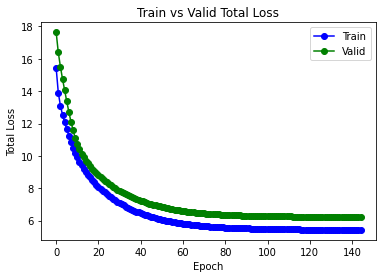

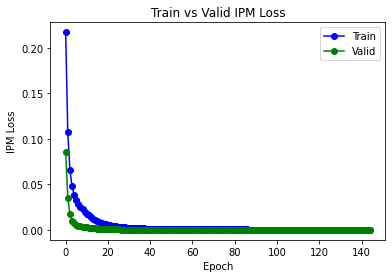

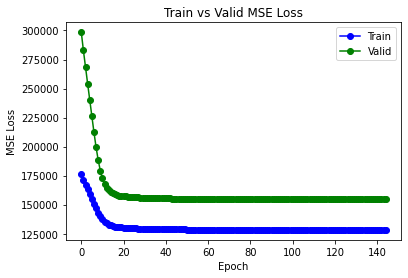

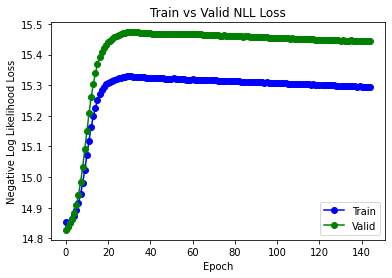

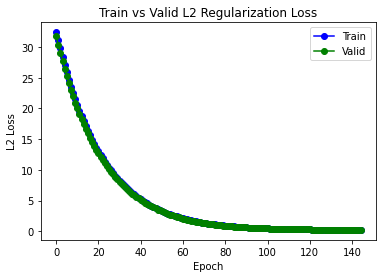

 72%|███████▏  | 144/200 [05:10<02:00,  2.16s/it]


In [ ]:
from sklearn.model_selection import ParameterGrid

param_grid = {'k' : [3], #6,10
              'distribution' : ['LogNormal'],
              'learning_rate' : [3e-4], #3e-4
              'layers' : [[100,100]],  #[100,100],[300,300], [300,100]
              'discount': [1],   #Censoring
              'imb_func': ['mmd2_lin'],
              'p_alpha': [10],  #Scaling IPM -Imbalance 2e-2,5e-1
              'p_beta': [3e-5],  #Scaling MSE 7e-6,1e-3,1e-5
              'p_gamma': [1e-1], #Scaling ELBO Loss 1e-1
              'p_lamda' : [0.2], #Scaling Regularization Loss 1.5e-1
             }
params = ParameterGrid(param_grid)

models = []

for param in params:
    model = survci_infoBase(k = param['k'],
                                 distribution = param['distribution'],
                                 layers = param['layers'],
                                 discount=param['discount'],
                                 imb_func=param['imb_func'],p_alpha=param['p_alpha'],p_beta = param['p_beta'],p_gamma = param['p_gamma'],p_lamda =param['p_lamda'])
    # The fit method is called to train the model
    model.fit(x_train,yf_train,ef_train,W_train,iters=200,learning_rate = param['learning_rate'])
    models.append([model.compute_ci(x_val,yf_val,ef_val,W_val), model.compute_mse_factual(x_val,yf_val,ef_val,W_val),model])  #hyperparameter selection based on Factual MSE 
#np.save('./Models/actg_semi_synthetic_info_models_23Jan.npy',models) #hyperparameter selection based on C-Index and Factual MSE 

In [ ]:
np.save('./Models/actg_semi_synthetic_info_models_23Jan.npy',models)

NameError: ignored

In [ ]:
#Hyperparameter Selection
import pdb 
cis = [] #Concordance Index for all the models
mse_f = [] #Mean Square Error computed on Factual Data for all the models 
for i in range(len(models)):
   cis.append(models[i][0])
   mse_f.append(float(models[i][1]))

#Normalizing the RMSE 
min_2, max_2 = 0, 1
rmse_f = np.sqrt(mse_f)
rmse_f_std = (np.array(rmse_f) - min(rmse_f)) / (max(rmse_f) - min(rmse_f))
rmse_f_scaled = rmse_f_std * (max_2 - min_2) + min_2
temp_metric = cis - abs(rmse_f_scaled)  
max_ci = max(cis)
min_mse = min(mse_f)
max_metric = max(temp_metric)

for i in range(len(models)):
  
  if models[i][0] == max_ci and models[i][1] == min_mse:
     best_model = models[i]
     print("Best Model Selected-1")
  elif temp_metric[i] == max_metric:
     best_model = models[i]
     print("Best Model Selected")

Best Model Selected-1


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in true_divide
  if sys.path[0] == '':


In [ ]:
# #Saving the Best Model
# if not os.path.isdir('./Models'):
#         os.makedirs('./Models')
# #np.save('Models/actg_semi_info_best_model.npy',best_model)
# #np.save('Models/synthetic_info_best_model.npy',best_model)
# np.save('./Models/actg_semi_synthetic_info_model_new1.npy',models)

In [ ]:
# model2 = np.load('Models/actg_semi_synthetic_info_model_1.npy',allow_pickle=True)
# model = model2[2]

In [ ]:
#best_model = np.load('Models/actg_semi_info_best_model.npy', allow_pickle=True)
model = best_model[2]
#Best Hyperparameters 
print('Number of Parametric Distibutions (K):', model.k)
print('Layers:', model.layers)
print('Disribution:', model.dist)
print('Imb Loss:', model.imb_func)
print('Scaling Parameter for IPM-Imbalance:', model.p_alpha)
print('Scaling MSE Loss:', model.p_beta)
print('Scaling ELBO Loss:',model.p_gamma)
print('Scaling Regularization Loss', model.p_lamda)
print('Scaling ELBO_censored Loss:',model.discount)


Number of Parametric Distibutions (K): 3
Layers: [100, 100]
Disribution: LogNormal
Imb Loss: mmd2_lin
Scaling Parameter for IPM-Imbalance: 10
Scaling MSE Loss: 3e-05
Scaling ELBO Loss: 0.1
Scaling Regularization Loss 0.2
Scaling ELBO_censored Loss: 1


# Testing

In [ ]:
from surv_ci_info.utilities import auc
import torch
#Distibution Parameters
shapef_co,scalef_co,logitsf_co, shapef_tr,scalef_tr,logitsf_tr,shapef_co_c,scalef_co_c,logitsf_co_c,shapef_tr_c,scalef_tr_c,logitsf_tr_c= model.predict_dist_parameters(x_test,torch.from_numpy(W_test)) #Predicted Factual Parameters 
shapecf_co,scalecf_co,logitscf_co, shapecf_tr,scalecf_tr,logitscf_tr,shapecf_co_c,scalecf_co_c,logitscf_co_c,shapecf_tr_c,scalecf_tr_c,logitscf_tr_c = model.predict_dist_parameters(x_test,torch.from_numpy(1-W_test)) #Predicted Counter Factual Parameters 
###########################
ytf_max = yf_test[ef_test==1] #Time-to-event/Uncensored Samples
ycf_max = yf_test[ef_test==0] #Time-to-censoring/Censored Samples
w_test_yt = W_test[ef_test==1] #Treatment indicator for Uncensored Samples 
w_test_yc = W_test[ef_test==0] #Treatment indicator for Censored Samples
#####################
# t_pred_f_co = auc(model, torch.from_numpy(ytf_max),shapef_co,scalef_co, logitsf_co ) #Predicted Factual Outcome (Treatment (w) = 0)
# t_pred_f_tr = auc(model,torch.from_numpy(ytf_max),shapef_tr,scalef_tr, logitsf_tr) #Predicted Factual Outcome (Treatment(W) = 1)
# t_pred_cf_co = auc(model, torch.from_numpy(ytf_max),shapecf_co,scalecf_co,logitscf_co ) #Predcited CounterFactual Outcome (Treatment (W)= 1 )
# t_pred_cf_tr = auc(model,torch.from_numpy(ytf_max),shapecf_tr,scalecf_tr,logitscf_tr)
# c_pred_f_co = auc(model, torch.from_numpy(ycf_max),shapef_co_c,scalef_co_c, logitsf_co_c ) #Predicted Factual Outcome (Treatment (w) = 0)
# c_pred_f_tr = auc(model,torch.from_numpy(ycf_max),shapef_tr_c,scalef_tr_c, logitsf_tr_c) #Predicted Factual Outcome (Treatment(W) = 1)
# c_pred_cf_co = auc(model, torch.from_numpy(ycf_max),shapecf_co_c,scalecf_co_c,logitscf_co_c ) #Predcited CounterFactual Outcome (Treatment (W)= 1 )
# c_pred_cf_tr = auc(model,torch.from_numpy(ycf_max),shapecf_tr_c,scalecf_tr_c,logitscf_tr_c)
t_pred_f_co = auc(model, torch.from_numpy(yf_test),shapef_co,scalef_co, logitsf_co ) #Predicted Factual Outcome (Treatment (w) = 0)
t_pred_f_tr = auc(model,torch.from_numpy(yf_test),shapef_tr,scalef_tr, logitsf_tr) #Predicted Factual Outcome (Treatment(W) = 1)
t_pred_cf_co = auc(model, torch.from_numpy(yf_test),shapecf_co,scalecf_co,logitscf_co ) #Predcited CounterFactual Outcome (Treatment (W)= 1 )
t_pred_cf_tr = auc(model,torch.from_numpy(yf_test),shapecf_tr,scalecf_tr,logitscf_tr)
c_pred_f_co = auc(model, torch.from_numpy(yf_test),shapef_co_c,scalef_co_c, logitsf_co_c ) #Predicted Factual Outcome (Treatment (w) = 0)
c_pred_f_tr = auc(model,torch.from_numpy(yf_test),shapef_tr_c,scalef_tr_c, logitsf_tr_c) #Predicted Factual Outcome (Treatment(W) = 1)
c_pred_cf_co = auc(model, torch.from_numpy(yf_test),shapecf_co_c,scalecf_co_c,logitscf_co_c ) #Predcited CounterFactual Outcome (Treatment (W)= 1 )
c_pred_cf_tr = auc(model,torch.from_numpy(yf_test),shapecf_tr_c,scalecf_tr_c,logitscf_tr_c)
y_pred_f_co = ef_test[W_test==0]*t_pred_f_co.detach().numpy() + (1-ef_test[W_test==0])*c_pred_f_co.detach().numpy()
y_pred_f_tr = ef_test[W_test==1]*t_pred_f_tr.detach().numpy() + (1-ef_test[W_test==1])*c_pred_f_tr.detach().numpy()
y_pred_cf_co = ecf_test[W_test==1]*t_pred_cf_co.detach().numpy() + (1-ecf_test[W_test==1])*c_pred_cf_co.detach().numpy()
y_pred_cf_tr = ecf_test[W_test==0]*t_pred_cf_tr.detach().numpy() + (1-ecf_test[W_test==0])*c_pred_cf_tr.detach().numpy()

Concordance Index

In [ ]:
from surv_ci_info.utilities import softmax_out, sample_lognormal, sample_weibull
from lifelines.utils import concordance_index
treated_idx = np.where(W_test>0)[0]                        
control_idx = np.where(W_test<1)[0]
c_index_co = concordance_index(event_times=yf_test[control_idx],predicted_scores=y_pred_f_co,event_observed=ef_test[control_idx])
c_index_tr = concordance_index(event_times=yf_test[treated_idx],predicted_scores=y_pred_f_tr,event_observed=ef_test[treated_idx])
ci_index = (c_index_co + c_index_tr) * 0.5
print('CI Index - Control', c_index_co)
print('CI Index - Treated', c_index_tr)
print('Avg CI ', ci_index)

CI Index - Control 0.6723900843646635
CI Index - Treated 0.7669115396388123
Avg CI  0.719650812001738


In [ ]:
#On yt
from surv_ci_info.utilities import softmax_out, sample_lognormal, sample_weibull
from lifelines.utils import concordance_index
treated_idx = np.where(W_test>0)[0]                        
control_idx = np.where(W_test<1)[0]
c_index_co = concordance_index(event_times=yf_test[control_idx],predicted_scores= t_pred_f_co.detach().numpy(),event_observed=ef_test[control_idx])
c_index_tr = concordance_index(event_times=yf_test[treated_idx],predicted_scores=t_pred_f_tr.detach().numpy(),event_observed=ef_test[treated_idx])
ci_index = (c_index_co + c_index_tr) * 0.5
print('CI Index - Control', c_index_co)
print('CI Index - Treated', c_index_tr)
print('Avg CI ', ci_index)

CI Index - Control 0.6060411788753856
CI Index - Treated 0.5549433731251913
Avg CI  0.5804922760002884


In [ ]:
# #Bootstrapping for CI
# ci_all = []
# ci_control = []
# ci_treated = []
# for _ in range(1000):
#   ind = np.random.randint(0, x_test.shape[0], x_test.shape[0])
#   yf = yf_test[ind]
#   #tcf = tcf_test[ind]
#   ef = ef_test[ind]
#   x = x_test[ind]
#   w = W_test[ind]

#   #Distibution Parameters
#   #shapef_co,scalef_co,logitsf_co, shapef_tr,scalef_tr,logitsf_tr,_,_,_,_,_,_ = model.predict_dist_parameters(x,torch.from_numpy(w))  #Predicted Factual Parameters 
#   shapef_co,scalef_co,logitsf_co, shapef_tr,scalef_tr,logitsf_tr,shapef_co_c,scalef_co_c,logitsf_co_c,shapef_tr_c,scalef_tr_c,logitsf_tr_c= model.predict_dist_parameters(x,torch.from_numpy(w)) #Predicted Factual Parameters 
#   #shapecf_co,scalecf_co,logitscf_co, shapecf_tr,scalecf_tr,logitscf_tr,shapecf_co_c,scalecf_co_c,logitscf_co_c,shapecf_tr_c,scalecf_tr_c,logitscf_tr_c = model.predict_dist_parameters(x,torch.from_numpy(1-w)) #Predicted Counter Factual Parameters 

#   #shapecf_co,scalecf_co,logitscf_co, shapecf_tr,scalecf_tr,logitscf_tr = model.predict_dist_parameters(x,torch.from_numpy(1-w))  #Predicted Counter Factual Parameters 

#   #Factual Outcomes 
#   t_pred_f_co = auc(model, torch.from_numpy(yf),shapef_co,scalef_co, logitsf_co ) #Predicted Factual Outcome (Treatment (w) = 0)
#   t_pred_f_tr = auc(model,torch.from_numpy(yf),shapef_tr,scalef_tr, logitsf_tr) #Predicted Factual Outcome (Treatment(W) = 1)
#   c_pred_f_co = auc(model, torch.from_numpy(yf),shapef_co_c,scalef_co_c, logitsf_co_c ) #Predicted Factual Outcome (Treatment (w) = 0)
#   c_pred_f_tr = auc(model,torch.from_numpy(yf),shapef_tr_c,scalef_tr_c, logitsf_tr_c)
#   y_pred_f_co = ef[w==0]*t_pred_f_co.detach().numpy() + (1-ef[w==0])*c_pred_f_co.detach().numpy()
#   y_pred_f_tr = ef[w==1]*t_pred_f_tr.detach().numpy() + (1-ef[w==1])*c_pred_f_tr.detach().numpy()
#   #y_pred_cf_co = ecf[w==1]*t_pred_cf_co.detach().numpy() + (1-ecf[W_test==1])*c_pred_cf_co.detach().numpy()
#   #y_pred_cf_tr = ecf[w==0]*t_pred_cf_tr.detach().numpy() + (1-ecf[W_test==0])*c_pred_cf_tr.detach().numpy()


#   treated_idx = np.where(w>0)[0]                        
#   control_idx = np.where(w<1)[0]
#   c_index_co = concordance_index(event_times=yf[control_idx],predicted_scores=y_pred_f_co,event_observed=ef[control_idx])
#   c_index_tr = concordance_index(event_times=yf[treated_idx],predicted_scores=y_pred_f_tr,event_observed=ef[treated_idx])

#   ci_index = (c_index_co + c_index_tr) * 0.5
#   ci_all.append(ci_index)
#   ci_control.append(c_index_co)
#   ci_treated.append(c_index_tr)



# # 95% confidence intervals
# def confidence_interval(metric):
#   lower =  np.percentile(metric, 2.5)
#   median = np.percentile(metric, 50)
#   upper =  np.percentile(metric, 97.5)  
#   return median,lower,upper

# median,lower,upper = confidence_interval(ci_all)
# print('Concordance Index_Avg:', "{} ({},{})".format(median,lower, upper))
# median_0,lower_0,upper_0 = confidence_interval(ci_control)
# print('Concordance Index_Control:', "{} ({},{})".format(median_0,lower_0, upper_0))
# median_1,lower_1,upper_1 = confidence_interval(ci_treated)
# print('Concordance Index_Treated:', "{} ({},{})".format(median_1,lower_1, upper_1))

Treatment Effect

In [ ]:
#Ground Truth Inidivdual Treatment Effect (ITE)
emp_ite_a = yf_test[W_test==1] - ycf_test[W_test==1]
emp_ite_b = ycf_test[W_test==0] - yf_test[W_test==0] 
emp_ite = np.concatenate((emp_ite_a, emp_ite_b), axis=0)

#Predicted ITE
pred_ite_a = y_pred_f_tr - y_pred_cf_co #Factual_Treatment=1
pred_ite_b = y_pred_cf_tr - y_pred_f_co #Factual_Treatment=0
pred_ite = np.concatenate((pred_ite_a, pred_ite_b), axis=0)

#Average Treatment Effect Metric
emp_ate = np.mean(emp_ite)
pred_ate =np.mean(pred_ite)
epsilon_ate = np.abs(emp_ate-pred_ate)

print("Ground Truth ATE: ", np.round(emp_ate, 4))
print("Predicted ATE: ", np.round(pred_ate,4))
print("Epsilon ATE: ", np.round(epsilon_ate, 4))

Ground Truth ATE:  -23.5945
Predicted ATE:  -2.3996
Epsilon ATE:  21.1949


In [ ]:
#Ground Truth Inidivdual Treatment Effect (ITE)
emp_ite_a = tf_test[W_test==1] - tcf_test[W_test==1]
emp_ite_b = tcf_test[W_test==0] - tf_test[W_test==0] 
emp_ite = np.concatenate((emp_ite_a, emp_ite_b), axis=0)

#Predicted ITE
pred_ite_a = t_pred_f_tr.detach().numpy() - t_pred_cf_co.detach().numpy() #Factual_Treatment=1
pred_ite_b = t_pred_cf_tr.detach().numpy() - t_pred_f_co.detach().numpy() #Factual_Treatment=0
pred_ite = np.concatenate((pred_ite_a, pred_ite_b), axis=0)

#Average Treatment Effect Metric
emp_ate = np.mean(emp_ite)
pred_ate =np.mean(pred_ite)
epsilon_ate = np.abs(emp_ate-pred_ate)

print("Ground Truth ATE: ", np.round(emp_ate, 4))
print("Predicted ATE: ", np.round(pred_ate,4))
print("Epsilon ATE: ", np.round(epsilon_ate, 4))

Ground Truth ATE:  -23.8554
Predicted ATE:  -30.7621
Epsilon ATE:  6.9067


PEHE

In [ ]:

#Bootstrapping

pehe_all = []
pehe_all_t = []
for _ in range(1000):
  ind = np.random.randint(0, x_test.shape[0], x_test.shape[0])
  
  yf = yf_test[ind]
  ycf = ycf_test[ind]
  tf = tf_test[ind]
  tcf = tcf_test[ind]
  ef = ef_test[ind]
  ecf = ecf_test[ind]
  x = x_test[ind]
  w = W_test[ind]

  #Ground Truth Individual Treatment Effect (ITE)
  emp_ite_a = yf[w==1] - ycf[w==1]
  emp_ite_b = ycf[w==0] - yf[w==0] 
  emp_ite = np.concatenate((emp_ite_a, emp_ite_b), axis=0)
  emp_ite_a_t = tf[w==1] - tcf[w==1]
  emp_ite_b_t = tcf[w==0] - tf[w==0] 
  emp_ite_t = np.concatenate((emp_ite_a_t, emp_ite_b_t), axis=0)
  

  #Distibution Parameters 
  shapef_co,scalef_co,logitsf_co, shapef_tr,scalef_tr,logitsf_tr,shapef_co_c,scalef_co_c,logitsf_co_c,shapef_tr_c,scalef_tr_c,logitsf_tr_c= model.predict_dist_parameters(x,torch.from_numpy(w)) #Predicted Factual Parameters 
  shapecf_co,scalecf_co,logitscf_co, shapecf_tr,scalecf_tr,logitscf_tr,shapecf_co_c,scalecf_co_c,logitscf_co_c,shapecf_tr_c,scalecf_tr_c,logitscf_tr_c = model.predict_dist_parameters(x,torch.from_numpy(1-w)) #Predicted Counter Factual Parameters 


  #Factual Outcomes 
  t_pred_f_co = auc(model, torch.from_numpy(yf),shapef_co,scalef_co, logitsf_co ) #Predicted Factual Outcome (Treatment (w) = 0)
  t_pred_f_tr = auc(model,torch.from_numpy(yf),shapef_tr,scalef_tr, logitsf_tr) #Predicted Factual Outcome (Treatment(W) = 1)
  t_pred_cf_co = auc(model, torch.from_numpy(yf),shapecf_co,scalecf_co, logitscf_co ) #Predicted CounterFactual Outcome (Treatment (w) = 0)
  t_pred_cf_tr = auc(model,torch.from_numpy(yf),shapecf_tr,scalecf_tr, logitscf_tr)
  c_pred_f_co = auc(model, torch.from_numpy(yf),shapef_co_c,scalef_co_c, logitsf_co_c ) #Predicted Factual Outcome (Treatment (w) = 0)
  c_pred_f_tr = auc(model,torch.from_numpy(yf),shapef_tr_c,scalef_tr_c, logitsf_tr_c)
  c_pred_cf_co = auc(model, torch.from_numpy(yf),shapecf_co_c,scalecf_co_c, logitscf_co_c ) #Predicted Counteractual Outcome (Treatment (w) = 0)
  c_pred_cf_tr = auc(model,torch.from_numpy(yf),shapecf_tr_c,scalecf_tr_c, logitscf_tr_c)
  y_pred_f_co = ef[w==0]*t_pred_f_co.detach().numpy() + (1-ef[w==0])*c_pred_f_co.detach().numpy()
  y_pred_f_tr = ef[w==1]*t_pred_f_tr.detach().numpy() + (1-ef[w==1])*c_pred_f_tr.detach().numpy()
  y_pred_cf_co = ecf[w==1]*t_pred_cf_co.detach().numpy() + (1-ecf[w==1])*c_pred_cf_co.detach().numpy()
  y_pred_cf_tr = ecf[w==0]*t_pred_cf_tr.detach().numpy() + (1-ecf[w==0])*c_pred_cf_tr.detach().numpy()

  pred_ite_a = y_pred_f_tr - y_pred_cf_co #Factual_Treatment=1
  pred_ite_b = y_pred_cf_tr - y_pred_f_co #Factual_Treatment=0
  pred_ite = np.concatenate((pred_ite_a, pred_ite_b), axis=0)

  pred_ite_a_t = t_pred_f_tr.detach().numpy() - t_pred_cf_co.detach().numpy() #Factual_Treatment=1
  pred_ite_b_t = t_pred_cf_tr.detach().numpy() - t_pred_f_co.detach().numpy() #Factual_Treatment=0
  pred_ite_t = np.concatenate((pred_ite_a_t, pred_ite_b_t), axis=0)
  
  emp_ate = np.mean(emp_ite)
  pred_ate =np.mean(pred_ite)

  emp_ate_t = np.mean(emp_ite_t)
  pred_ate_t =np.mean(pred_ite_t)

  #PEHE Metric
  pehe = (emp_ite-pred_ite)**2
  pehe_all.append(np.round(np.sqrt(np.mean(pehe)), 4))  #\epsilon_{pehe}

  pehe_t = (emp_ite_t-pred_ite_t)**2
  pehe_all_t.append(np.round(np.sqrt(np.mean(pehe_t)), 4))  #\epsilon_{pehe}

# 95% confidence intervals
def confidence_interval(metric):
  lower =  np.percentile(metric, 2.5)
  median = np.percentile(metric, 50)
  upper =  np.percentile(metric, 97.5)  
  return median,lower,upper

median,lower,upper = confidence_interval(pehe_all)
median_t,lower_t,upper_t = confidence_interval(pehe_all_t)
print('PEHE:', "{} ({},{})".format(median,lower, upper))
print('PEHE:', "{} ({},{})".format(median_t,lower_t, upper_t))

PEHE: 497.1249 (436.00720250000006,560.84798)
PEHE: 1002.0209 (881.6000224999999,1140.9221875)


Parametric Hazard Ratio

In [ ]:
def lognormal_pdf(mu, sigma, t):
  a = 1/(t*sigma*np.sqrt(2*np.pi))
  b = ((np.log(t) - mu)**2)/(2*(sigma**2))
  pdf = a*np.exp(-b)
  return pdf

def lognormal_surv(mu,sigma,t):
  s = (np.log(t) - mu)/ sigma*np.sqrt(2)
  s = 0.5 - 0.5*np.array(torch.erf(torch.from_numpy(s)))
  return s

def compute_HR(T0,T1,mu0, sigma0, mu1, sigma1):
  pdf_0 = lognormal_pdf(mu0, np.exp(sigma0), T0)
  pdf_1 = lognormal_pdf(mu1, np.exp(sigma1), T1)
  surv_0 = lognormal_surv(mu0,np.exp(sigma0), T0)
  surv_1 = lognormal_surv(mu1, np.exp(sigma1), T1)
  hr = (pdf_1/pdf_0)*(surv_0/surv_1)
  return hr
  
shapef_0, scalef_0 = softmax_out(shapef_co,scalef_co, logitsf_co)
shapef_1, scalef_1= softmax_out(shapef_tr,scalef_tr,logitsf_tr)
shapecf_0, scalecf_0 = softmax_out(shapecf_co,scalecf_co, logitscf_co)
shapecf_1, scalecf_1 = softmax_out(shapecf_tr,scalecf_tr,logitscf_tr)

shape_co = np.concatenate((shapef_0.detach().numpy(), shapecf_0.detach().numpy()), axis=0)
scale_co =  np.concatenate((scalef_0.detach().numpy(), scalecf_0.detach().numpy()), axis=0)
shape_tr = np.concatenate((shapef_1.detach().numpy(), shapecf_1.detach().numpy()), axis=0)
scale_tr = np.concatenate((scalef_1.detach().numpy(), scalecf_1.detach().numpy()), axis=0)


T_0_pred = torch.cat((t_pred_f_co, t_pred_cf_co), dim=0)
T_1_pred = torch.cat((t_pred_f_tr, t_pred_cf_tr), dim=0)

hr_pred = compute_HR(T_0_pred.detach().numpy(), T_1_pred.detach().numpy(), shape_co, scale_co, shape_tr, scale_tr)
print('Hazard Ratio- median:', "{}".format(np.round(np.median(hr_pred),4)))
print('Hazard Ratio- mean:', "{}".format(np.round(np.mean(hr_pred),4)))

Hazard Ratio- median: 0.8785
Hazard Ratio- mean: 0.889
